=== LOAD DATA ===
Shape: (714, 8)
Kolom: ['survived', 'pclass', 'name', 'sex', 'age', 'fare', 'sibsp', 'parch']

5 data pertama:
   survived  pclass                                               name  \
0         0       3                            Braund, Mr. Owen Harris   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2         1       3                             Heikkinen, Miss. Laina   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4         0       3                           Allen, Mr. William Henry   

      sex   age     fare  sibsp  parch  
0    male  22.0   7.2500      1      0  
1  female  38.0  71.2833      1      0  
2  female  26.0   7.9250      0      0  
3  female  35.0  53.1000      1      0  
4    male  35.0   8.0500      0      0  

=== EKSPLORASI DATA ===

Info dataset:
RangeIndex: 714 entries, 0 to 713
Data columns: 8

Column Info:
  survived: int64, 714 non-null, 0 null
  pclass: int64, 714 non-null, 0 nul

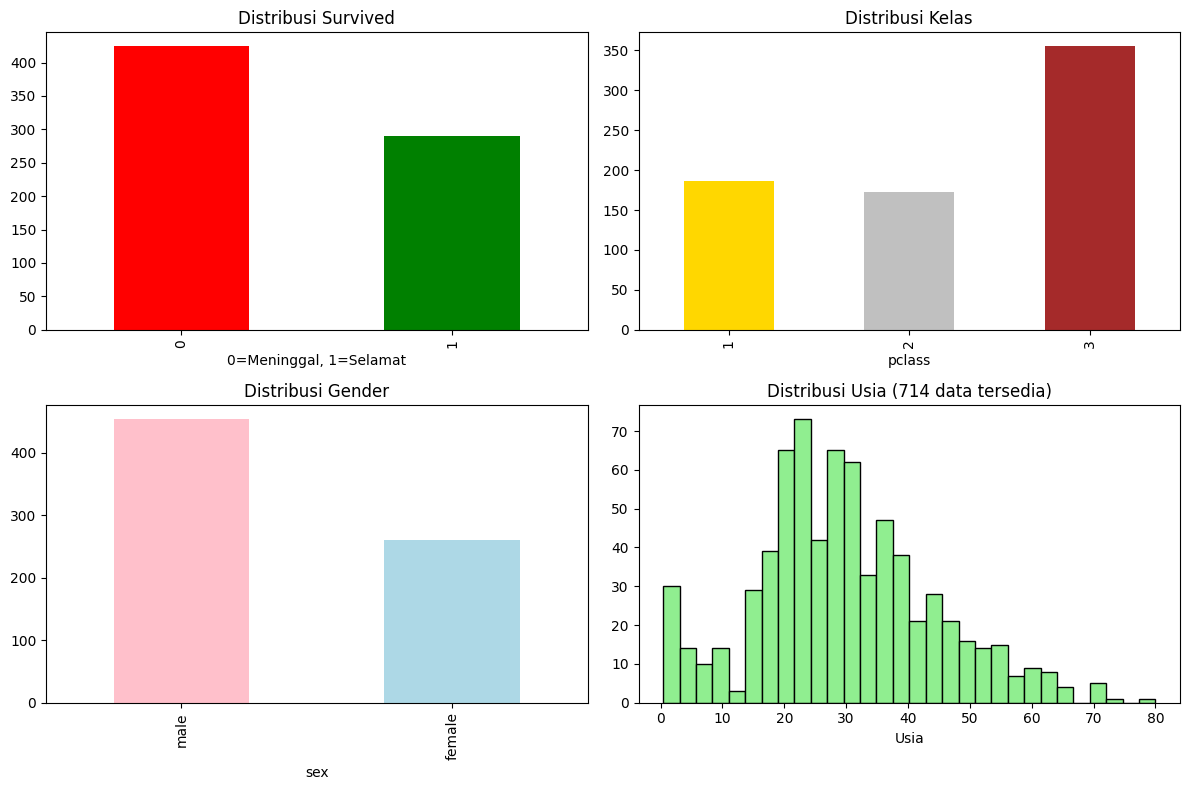


=== DETEKSI MASALAH DATA ===

1. MISSING VALUES:
Tidak ada missing values

2. DETEKSI OUTLIER:
  age: 11 outlier
  fare: 94 outlier
  sibsp: 35 outlier
  parch: 15 outlier

3. DATA TIDAK KONSISTEN:
  Nilai unik di pclass: [np.int64(1), np.int64(2), np.int64(3)]
  Nilai unik di sex: ['male', 'female']

=== IMPUTASI DATA ===
Missing values sebelum: 0
Missing values sesudah: 0


<Figure size 800x400 with 0 Axes>

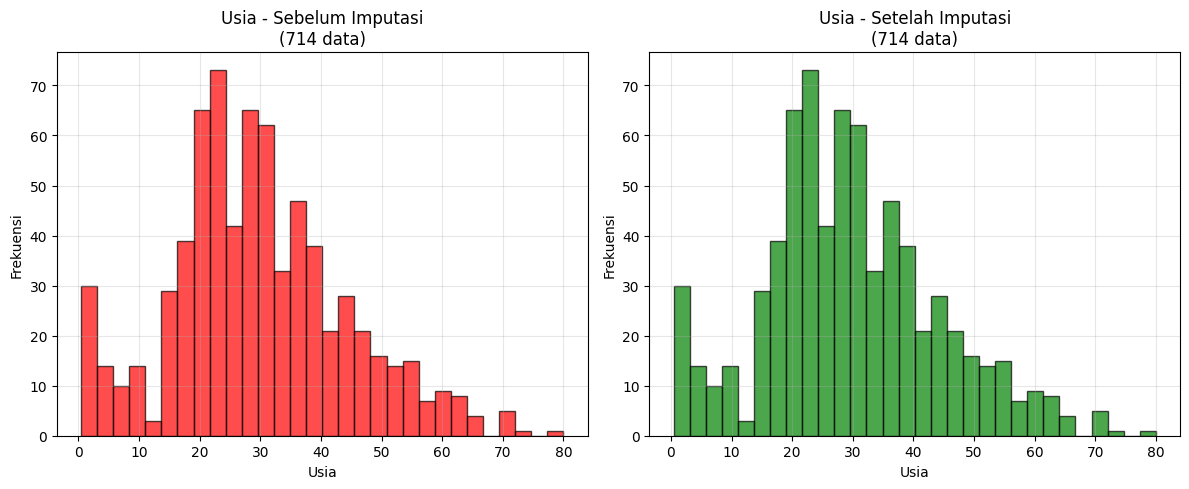


RINGKASAN PROSES
Data awal: (714, 8)
Missing values awal: 0
Missing values akhir: 0
Usia sebelum: mean=29.7, count=714
Usia sesudah: mean=29.7, count=714


In [5]:
# ANALISIS DATA TITANIC - DASAR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========== LOAD DATA ==========
print("=== LOAD DATA ===")
df = pd.read_csv('titanic.csv')
print(f"Shape: {df.shape}")
print(f"Kolom: {list(df.columns)}")
print("\n5 data pertama:")
print(df.head())

# ========== EKSPLORASI DATA ==========
print("\n=== EKSPLORASI DATA ===")

print("\nInfo dataset:")
print(f"RangeIndex: {len(df)} entries, 0 to {len(df)-1}")
print(f"Data columns: {len(df.columns)}")
print("\nColumn Info:")
for col in df.columns:
    dtype = df[col].dtype
    non_null = df[col].count()
    null_count = df[col].isnull().sum()
    print(f"  {col}: {dtype}, {non_null} non-null, {null_count} null")

print("\nStatistik deskriptif:")
print(df.describe())

print("\nDistribusi data kategorikal:")
print(f"Survived: {df['survived'].value_counts().to_dict()}")
print(f"Pclass: {df['pclass'].value_counts().to_dict()}")
print(f"Sex: {df['sex'].value_counts().to_dict()}")

# Visualisasi distribusi
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
df['survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Distribusi Survived')
plt.xlabel('0=Meninggal, 1=Selamat')

plt.subplot(2, 2, 2)
df['pclass'].value_counts().sort_index().plot(kind='bar', color=['gold', 'silver', 'brown'])
plt.title('Distribusi Kelas')

plt.subplot(2, 2, 3)
df['sex'].value_counts().plot(kind='bar', color=['pink', 'lightblue'])
plt.title('Distribusi Gender')

plt.subplot(2, 2, 4)
# Handle missing values untuk visualisasi usia
age_data = df['age'].dropna()
plt.hist(age_data, bins=30, color='lightgreen', edgecolor='black')
plt.title(f'Distribusi Usia ({len(age_data)} data tersedia)')
plt.xlabel('Usia')

plt.tight_layout()
plt.show()

# ========== DETEKSI MASALAH DATA ==========
print("\n=== DETEKSI MASALAH DATA ===")

# Missing values
print("\n1. MISSING VALUES:")
missing_data = df.isnull().sum()
for col in df.columns:
    if df[col].isnull().sum() > 0:
        missing_count = df[col].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100
        print(f"  {col}: {missing_count} ({missing_pct:.1f}%)")

# Visualisasi missing values
plt.figure(figsize=(8, 4))
missing_cols = [col for col in df.columns if df[col].isnull().sum() > 0]
missing_counts = [df[col].isnull().sum() for col in missing_cols]

if missing_cols:  # Only plot if there are missing values
    plt.bar(missing_cols, missing_counts, color='red', alpha=0.7)
    plt.title('Missing Values per Kolom')
    plt.ylabel('Jumlah Missing')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada missing values")

# Outlier detection
print("\n2. DETEKSI OUTLIER:")
numeric_cols = ['age', 'fare', 'sibsp', 'parch']
for col in numeric_cols:
    if col in df.columns:
        # Handle missing values untuk perhitungan outlier
        col_data = df[col].dropna()
        if len(col_data) > 0:
            Q1 = col_data.quantile(0.25)
            Q3 = col_data.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            outliers = col_data[(col_data < lower) | (col_data > upper)]
            print(f"  {col}: {len(outliers)} outlier")

# Data tidak konsisten
print("\n3. DATA TIDAK KONSISTEN:")
print(f"  Nilai unik di pclass: {sorted(df['pclass'].unique())}")
print(f"  Nilai unik di sex: {df['sex'].unique().tolist()}")

# ========== IMPUTASI DATA ==========
print("\n=== IMPUTASI DATA ===")
df_clean = df.copy()

print(f"Missing values sebelum: {df_clean.isnull().sum().sum()}")

# Imputasi age dengan median berdasarkan kelompok
if 'age' in df_clean.columns and df_clean['age'].isnull().any():
    # Hitung median untuk setiap kombinasi sex dan pclass
    age_medians = df_clean.groupby(['sex', 'pclass'])['age'].median()
    print(f"\nMedian usia per kelompok:")
    for (sex, pclass), median_age in age_medians.items():
        print(f"  {sex}, kelas {pclass}: {median_age:.1f} tahun")
    
    def impute_age(row):
        if pd.isna(row['age']):
            return age_medians.get((row['sex'], row['pclass']), df_clean['age'].median())
        return row['age']
    
    df_clean['age'] = df_clean.apply(impute_age, axis=1)
    print("✅ Age diimputasi dengan median kelompok")

# Imputasi fare dengan median (jika ada missing values)
if 'fare' in df_clean.columns and df_clean['fare'].isnull().any():
    fare_median = df_clean['fare'].median()
    df_clean['fare'].fillna(fare_median, inplace=True)
    print(f"✅ Fare diimputasi dengan median: ${fare_median:.2f}")

print(f"Missing values sesudah: {df_clean.isnull().sum().sum()}")

# Visualisasi perbandingan usia
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
age_before = df['age'].dropna()
plt.hist(age_before, bins=30, color='red', alpha=0.7, edgecolor='black')
plt.title(f'Usia - Sebelum Imputasi\n({len(age_before)} data)')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df_clean['age'], bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title(f'Usia - Setelah Imputasi\n({len(df_clean["age"])} data)')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Ringkasan akhir
print("\n" + "="*50)
print("RINGKASAN PROSES")
print("="*50)
print(f"Data awal: {df.shape}")
print(f"Missing values awal: {df.isnull().sum().sum()}")
print(f"Missing values akhir: {df_clean.isnull().sum().sum()}")
print(f"Usia sebelum: mean={df['age'].mean():.1f}, count={df['age'].count()}")
print(f"Usia sesudah: mean={df_clean['age'].mean():.1f}, count={df_clean['age'].count()}")
print("="*50)